In [95]:
import pandas as pd
import numpy as  np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats 
import math
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

In [96]:
df = pd.read_csv("final.csv")

In [97]:
df

,DATE,Month,PRCP,TMAX,TMIN,AWND,TDIFF,WSF2,WSF5,intense,count of dry days,count of wet days
0,1995-11-01,11,0.183214,57.083333,47.291667,6.93500,9.791667,13.0000,17.9000,0,0,6
1,1995-11-02,11,0.728929,64.782609,52.130435,7.44000,12.652174,14.1000,17.9000,0,0,7
2,1995-11-03,11,0.137500,70.250000,54.333333,7.88750,15.916667,15.0000,19.9000,0,0,8
3,1995-11-04,11,0.015357,60.250000,37.375000,14.65250,22.875000,21.9000,30.0000,0,0,9
4,1995-11-05,11,0.000714,48.458333,32.333333,10.28750,16.125000,15.0000,19.9000,0,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...
10313,2024-12-27,12,0.000000,39.400000,20.933333,2.71125,18.466667,9.4125,15.4250,0,2,0
10314,2024-12-28,12,0.252195,45.266667,29.066667,2.07000,16.200000,7.7875,11.4500,0,0,1
10315,2024-12-29,12,0.461310,54.133333,41.466667,7.60500,12.666667,21.9500,33.5125,0,0,2
10316,2024-12-30,12,0.369213,59.066667,45.200000,11.94125,13.866667,24.5000,36.7000,0,0,3


In [98]:
# Create a binary 1 for rain, 0 for no rain

df["prcp"] = np.where(df["PRCP"] == 0., 1, 0)

In [99]:
X = df[["Month","TMAX","TMIN","AWND","TDIFF","WSF2","WSF5"]]

y = df["prcp"]

Split the Data

In [100]:
kf = KFold(shuffle=True, random_state=2, n_splits=3)

In [101]:
for train_index, test_index in kf.split(X):
    print("Train index:", train_index[:10], len(train_index))
    print("Test index:",test_index[:10], len(test_index))
    print('')

Train index: [ 0  1  5  7  9 11 12 13 14 17] 6878
Test index: [ 2  3  4  6  8 10 15 16 18 20] 3440

Train index: [ 1  2  3  4  6  8  9 10 12 14] 6879
Test index: [ 0  5  7 11 13 19 21 34 35 36] 3439

Train index: [ 0  2  3  4  5  6  7  8 10 11] 6879
Test index: [ 1  9 12 14 17 23 24 25 26 29] 3439



Logistic Regression

,lr,l1,l2
precision,0.624585,0.738739,0.672956
recall,0.212190,0.092551,0.120767
fscore,0.316765,0.164493,0.204785
accuracy,0.764244,0.757849,0.758430
auc,0.243692,0.246532,0.249074


,lr,l1,l2
precision,0.556180,0.547401,0.556851
recall,0.249685,0.225725,0.240858
fscore,0.344648,0.319643,0.336268
accuracy,0.781041,0.778424,0.780750
auc,0.254308,0.253575,0.254286


,lr,l1,l2
precision,0.543814,0.548747,0.554054
recall,0.279470,0.260927,0.271523
fscore,0.369204,0.353680,0.364444
accuracy,0.790346,0.790637,0.792091
auc,0.237484,0.238073,0.237676


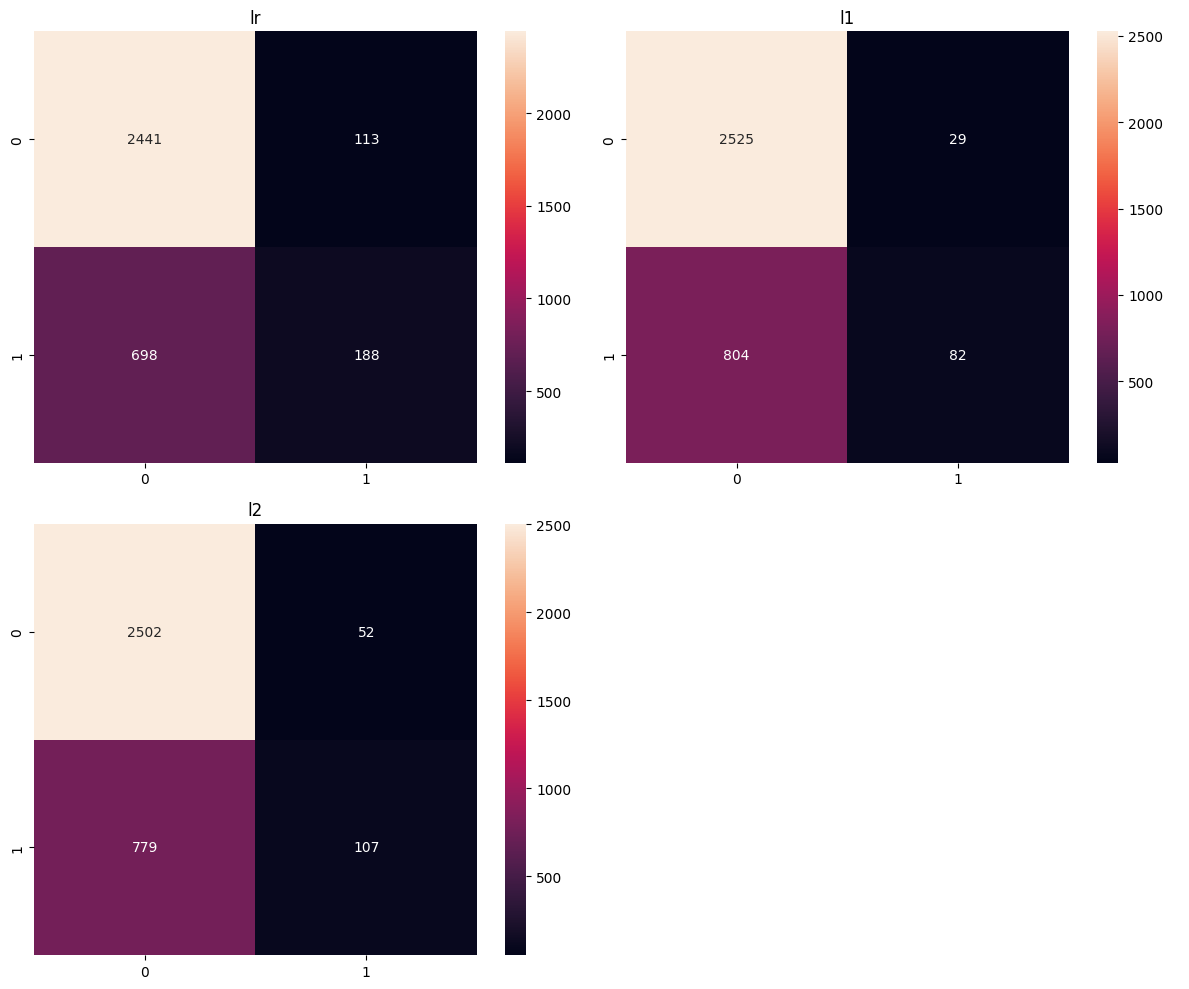

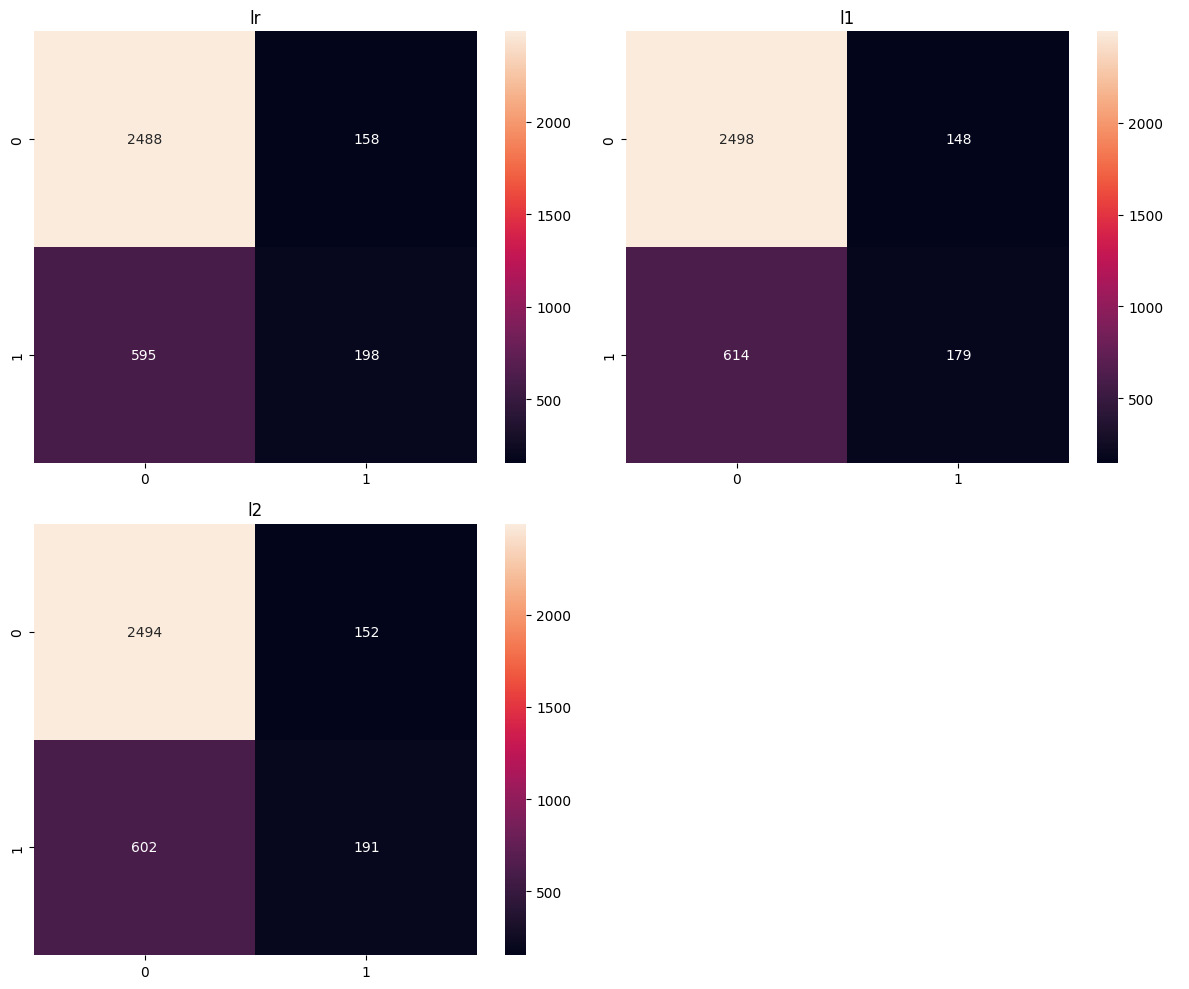

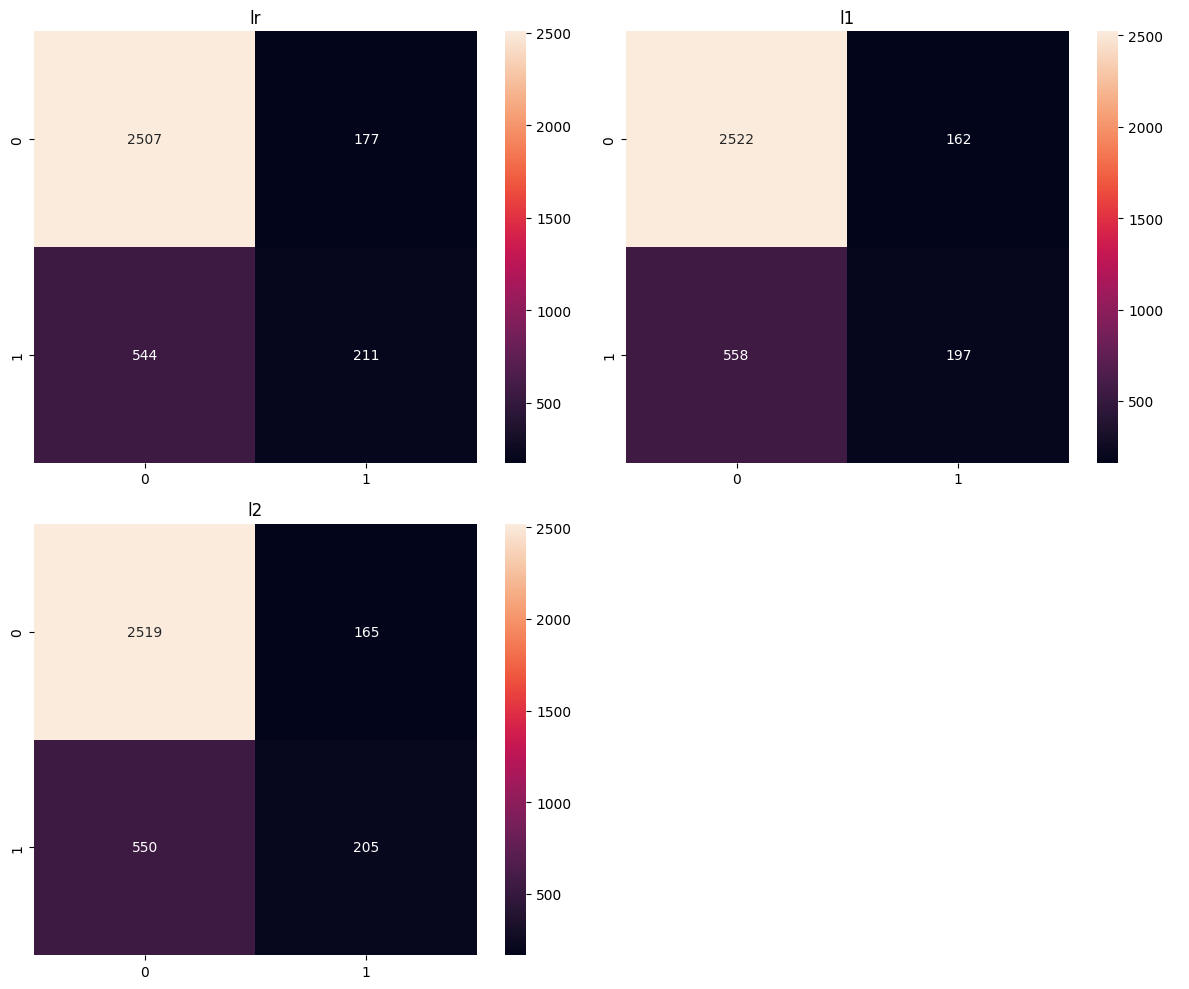

In [102]:
s = StandardScaler()
lr = LogisticRegression(solver='liblinear')
lr1 = LogisticRegressionCV(Cs=10, cv=4, penalty='l1', solver='liblinear')
lr2 = LogisticRegressionCV(Cs=10, cv=4, penalty='l2', solver='liblinear')

for train_index, test_index in kf.split(X):
    X_train, X_test, y_train, y_test = (X.iloc[train_index, :], 
                                        X.iloc[test_index, :], 
                                        y[train_index], 
                                        y[test_index])
    
    X_train_s = s.fit_transform(X_train)
    X_test_s = s.fit_transform(X_test)
    
    lr.fit(X_train_s, y_train)
    lr1.fit(X_train_s, y_train)
    lr2.fit(X_train_s, y_train)

    # Combine all the coefficients into a dataframe
    coefficients = {}
    y_pred = {}
    y_prob = {}
    cm = {}
    metrics = []

    coeff_labels = ['lr', 'l1', 'l2']
    coeff_models = [lr, lr1, lr2]

    for label, model in zip(coeff_labels, coeff_models):
        coeffs = model.coef_
        coefficients[label] = list(coeffs[0])

        # PREDICT
        y_pred[label] = model.predict(X_test_s).astype(float)
        y_prob[label] = model.predict_proba(X_test_s).max(axis=1)


        precision = precision_score(y_test, y_pred[label])
        recall = recall_score(y_test, y_pred[label])
        f1 = f1_score(y_test, y_pred[label])

        # The usual way to calculate accuracy
        accuracy = accuracy_score(y_test, y_pred[label])
    
        # ROC-AUC scores can be calculated by binarizing the data
        auc = roc_auc_score(y_test, y_prob[label], average='weighted')
    
        # Last, the confusion matrix
        cm[label] = confusion_matrix(y_test, y_pred[label])
    
        metrics.append(pd.Series({'precision':precision, 'recall':recall, 
                                'fscore':f1, 'accuracy':accuracy,
                                'auc':auc}, 
                                name=label))

    metrics = pd.concat(metrics, axis=1)
        
    coefficients = pd.DataFrame(coefficients)
    pred = pd.DataFrame(y_pred)
    prob = pd.DataFrame(y_prob)


    fig, axList = plt.subplots(nrows=2, ncols=2)
    axList = axList.flatten()
    fig.set_size_inches(12, 10)

    axList[-1].axis('off')

    for ax,lab in zip(axList[:-1], coeff_labels):
        sns.heatmap(cm[lab], ax=ax, annot=True, fmt='d');
        ax.set(title=lab);
    
    plt.tight_layout()

    display(metrics)




        

Random Forest

In [104]:
from sklearn.ensemble import RandomForestClassifier

,RandomForest
precision,0.527094
recall,0.241535
fscore,0.331269
accuracy,0.748837
auc,0.267157


,RandomForest
precision,0.527778
recall,0.287516
fscore,0.372245
accuracy,0.776388
auc,0.280743


,RandomForest
precision,0.528736
recall,0.304636
fscore,0.386555
accuracy,0.787729
auc,0.289385


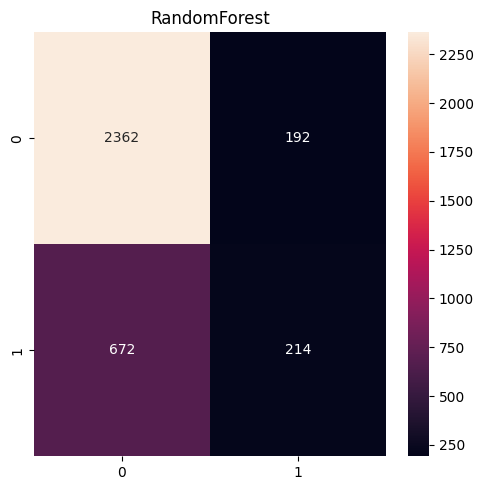

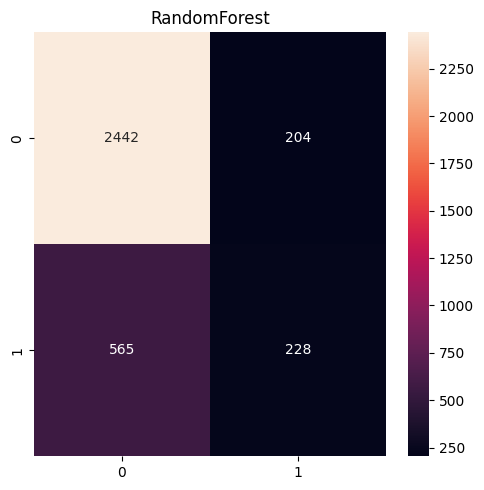

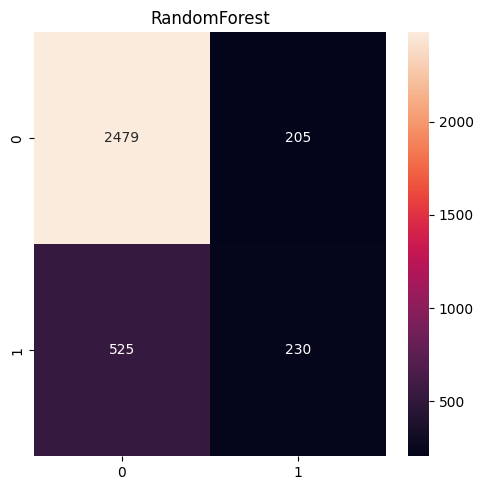

In [115]:
s = StandardScaler()
forest = RandomForestClassifier(max_features=round(np.sqrt(X.shape[1]))-1,
                               n_estimators=20, random_state=0)

for train_index, test_index in kf.split(X):
    X_train, X_test, y_train, y_test = (X.iloc[train_index, :], 
                                        X.iloc[test_index, :], 
                                        y[train_index], 
                                        y[test_index])
    
    X_train_s = s.fit_transform(X_train)
    X_test_s = s.fit_transform(X_test)
    
    forest.fit(X_train_s, y_train)
    # Combine all the coefficients into a dataframe
    y_pred = {}
    y_prob = {}
    cm = {}
    metrics = []

    # PREDICT
    y_pred = forest.predict(X_test_s).astype(float)
    y_prob = forest.predict_proba(X_test_s).max(axis=1)


    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # The usual way to calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # ROC-AUC scores can be calculated by binarizing the data
    auc = roc_auc_score(y_test, y_prob, average='weighted')

    # Last, the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    metrics.append(pd.Series({'precision':precision, 'recall':recall, 
                            'fscore':f1, 'accuracy':accuracy,
                            'auc':auc}, 
                            name="RandomForest"))

    metrics = pd.concat(metrics, axis=1)
    pred = pd.DataFrame(y_pred)
    prob = pd.DataFrame(y_prob)

    fig, ax = plt.subplots(nrows=1, ncols=1)
    fig.set_size_inches(5, 5)
    sns.heatmap(cm, ax=ax, annot=True, fmt='d')
    ax.set(title="RandomForest")
    
    plt.tight_layout()

    display(metrics)




        

KNN

In [116]:
from sklearn.neighbors import KNeighborsClassifier

,KNN
precision,0.524590
recall,0.180587
fscore,0.268682
accuracy,0.746802
auc,0.414256


,KNN
precision,0.431746
recall,0.171501
fscore,0.245487
accuracy,0.756906
auc,0.401386


,KNN
precision,0.441358
recall,0.189404
fscore,0.265060
accuracy,0.769410
auc,0.419041


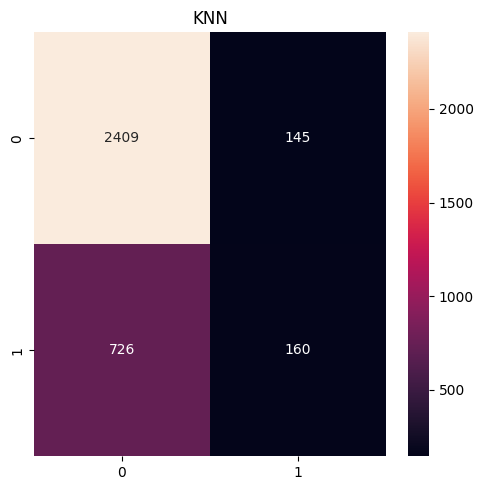

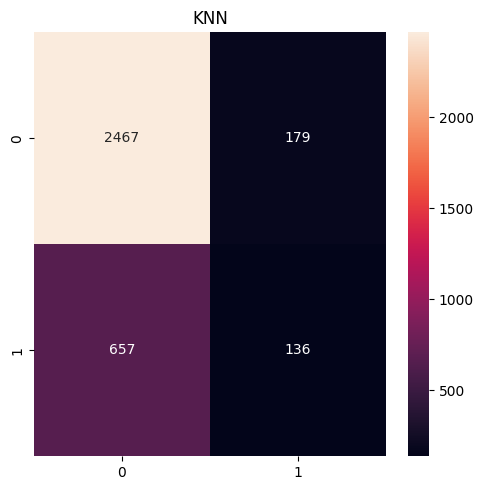

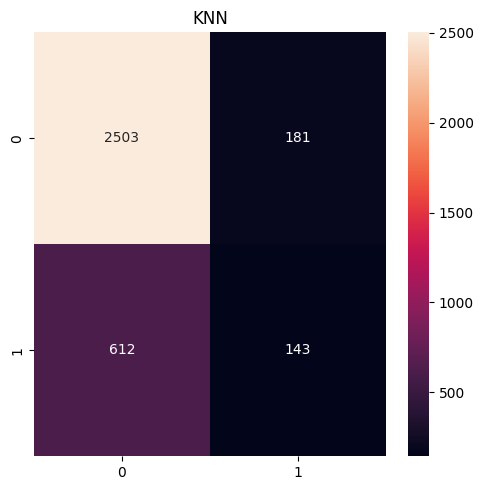

In [122]:
s = StandardScaler()
knn_model = KNeighborsClassifier(n_neighbors=2)

for train_index, test_index in kf.split(X):
    X_train, X_test, y_train, y_test = (X.iloc[train_index, :], 
                                        X.iloc[test_index, :], 
                                        y[train_index], 
                                        y[test_index])
    
    X_train_s = s.fit_transform(X_train)
    X_test_s = s.fit_transform(X_test)
    
    knn_model.fit(X_train_s, y_train.values.ravel())
    # Combine all the coefficients into a dataframe
    y_pred = {}
    y_prob = {}
    cm = {}
    metrics = []

    # PREDICT
    y_pred = knn_model.predict(X_test_s).astype(float)
    y_prob = knn_model.predict_proba(X_test_s).max(axis=1)


    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # The usual way to calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # ROC-AUC scores can be calculated by binarizing the data
    auc = roc_auc_score(y_test, y_prob, average='weighted')

    # Last, the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    metrics.append(pd.Series({'precision':precision, 'recall':recall, 
                            'fscore':f1, 'accuracy':accuracy,
                            'auc':auc}, 
                            name="KNN"))

    metrics = pd.concat(metrics, axis=1)
    pred = pd.DataFrame(y_pred)
    prob = pd.DataFrame(y_prob)

    fig, ax = plt.subplots(nrows=1, ncols=1)
    fig.set_size_inches(5, 5)
    sns.heatmap(cm, ax=ax, annot=True, fmt='d')
    ax.set(title="KNN")
    
    plt.tight_layout()

    display(metrics)




        